In [19]:
import sectio
# Section_n = sectio.db.get_section('sections_rhs', "RHS80x40x4", subdivision='calc')
# Section_n = sectio.db.get_section('sections_heaa', "HE100AA", subdivision=256)
Section_n = sectio.db.get_section('sections_ue', "UE140", subdivision=256)


Section_n

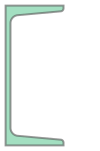

In [20]:
Section_n.polygon

In [21]:
Section_n.has_holes

False

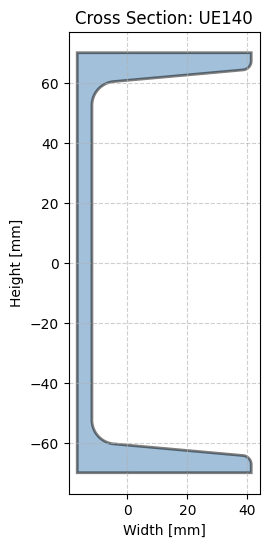

In [22]:
import matplotlib.pyplot as plt


def plot_section(cs):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot the exterior
    x, y = cs.polygon.exterior.xy
    ax.fill(x, y, alpha=0.5, fc='steelblue', ec='black', lw=2)

    # Plot any holes (if present)
    for interior in cs.polygon.interiors:
        xi, yi = interior.xy
        ax.fill(xi, yi, fc='white', ec='black', lw=1)

    ax.set_aspect('equal')
    ax.set_title(f"Cross Section: {cs.metadata.get('Section_ID', 'Unknown')}")
    ax.set_xlabel("Width [mm]")
    ax.set_ylabel("Height [mm]")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()


plot_section(Section_n)

In [23]:
import meshpy.triangle as triangle


def mesh_section(cs, max_area=5.0):
    points = []
    facets = []

    # Helper to add a loop (exterior or interior) to the mesh info
    def add_loop(coords):
        start_idx = len(points)
        new_points = list(coords)[:-1]
        points.extend(new_points)
        for i in range(len(new_points)):
            facets.append((start_idx + i, start_idx + (i + 1) %
                          len(new_points)))

    # 1. Add Exterior
    add_loop(cs.polygon.exterior.coords)

    # 2. Add Interiors and identify hole points
    holes = []
    if cs.has_holes:
        for interior in cs.polygon.interiors:
            add_loop(interior.coords)
            # Use the centroid of the hole as the "exclusion point"
            from shapely.geometry import Polygon
            hole_poly = Polygon(interior)
            holes.append((hole_poly.centroid.x, hole_poly.centroid.y))

    # 3. Define mesh info
    info = triangle.MeshInfo()
    info.set_points(points)
    info.set_facets(facets)
    if holes:
        info.set_holes(holes)  # This is the magic line

    # 4. Build mesh
    mesh = triangle.build(info, max_volume=max_area)
    return mesh

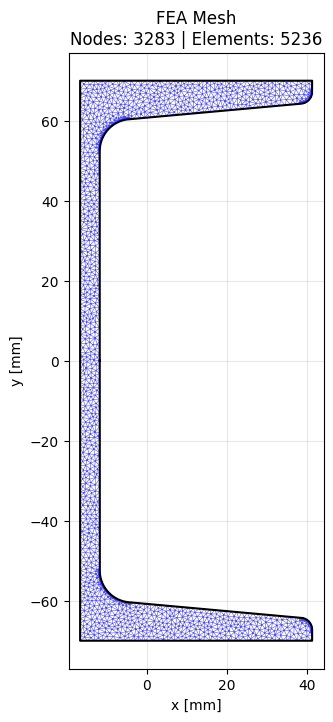

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate the mesh
# For HE100AA (tw=4.2), max_area=1.0 is quite fine
mesh = mesh_section(Section_n, max_area=1)

# 2. Extract mesh data
mesh_points = np.array(mesh.points)
mesh_tris = np.array(mesh.elements)

# 3. Plotting
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# Plot the triangulation
ax.triplot(mesh_points[:, 0], mesh_points[:, 1],
           mesh_tris, color='blue', lw=0.4, alpha=0.7)

# Highlight the boundary
x_ext, y_ext = Section_n.polygon.exterior.xy
ax.plot(x_ext, y_ext, color='black', lw=1.5)

ax.set_title(
    f"FEA Mesh\nNodes: {len(mesh.points)} | Elements: {len(mesh.elements)}")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
mesh

In [26]:
Section_n.area

1541.8908610661153

In [27]:
points = np.array(mesh.points)
elements = np.array(mesh.elements)

iy_total = 0
iz_total = 0

for tri in elements:
    # Get nodal coordinates
    tri_coords = points[tri]
    x = tri_coords[:, 0]
    y = tri_coords[:, 1]

    # Area of the triangle
    area = 0.5 * abs(x[0]*(y[1] - y[2]) + x[1] *
                     (y[2] - y[0]) + x[2]*(y[0] - y[1]))

    # Exact integral of y^2 dA (Moment of inertia about X-axis, Iy)
    # Iy = (Area/12) * (y1^2 + y2^2 + y3^2 + (y1+y2+y3)^2)
    iy_tri = (area / 12.0) * (y[0]**2 + y[1]**2 +
                              y[2]**2 + (y[0] + y[1] + y[2])**2)

    # Exact integral of x^2 dA (Moment of inertia about Y-axis, Iz)
    iz_tri = (area / 12.0) * (x[0]**2 + x[1]**2 +
                              x[2]**2 + (x[0] + x[1] + x[2])**2)

    iy_total += iy_tri
    iz_total += iz_tri

print(f"Mesh Calculated Iy: {iy_total:,.2f} mm⁴")
print(f"Mesh Calculated Iz: {iz_total:,.2f} mm⁴")

Mesh Calculated Iy: 4,826,233.57 mm⁴
Mesh Calculated Iz: 450,274.25 mm⁴


In [28]:
4.91/4.8262

1.0173635572500104

In [29]:
4.54/4.50274

1.008274961467906